In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
train = pd.read_csv("mlp-jan-2026-kaggle-assignment-2/train.csv")
test = pd.read_csv("mlp-jan-2026-kaggle-assignment-2/test.csv")
sample = pd.read_csv("mlp-jan-2026-kaggle-assignment-2/sample_submission.csv")


In [3]:
train["is_train"] = 1
test["is_train"] = 0
df = pd.concat((train, test))

In [4]:
df.shape, train.shape, test.shape

((8124, 27), (7000, 27), (1124, 26))

# Main code starts:

## EDA and Feature Engineering for Mushroom Dataset

In [56]:
df.dtypes

cap-shape                       str
cap-surface                     str
cap-color                       str
bruises                         str
number_of_bruises             int64
odor                            str
gill-attachment                 str
gill-spacing                    str
gill-size                       str
gill-color                      str
stalk-shape                     str
stalk-root                      str
stalk-surface-above-ring        str
stalk-surface-below-ring        str
stalk-color-above-ring          str
stalk-color-below-ring          str
ring-number                 float64
ring-type                       str
spore-print-color               str
population                      str
habitat                         str
class                       float64
is_train                      int64
dtype: object

In [57]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_bruises,8124.0,5.177253,7.630491,0.0,0.0,0.0,10.0,24.0
ring-number,8124.0,1.074184,0.261505,1.0,1.0,1.0,1.0,2.0
class,7000.0,0.469714,0.499118,0.0,0.0,0.0,1.0,1.0
is_train,8124.0,0.861645,0.345294,0.0,1.0,1.0,1.0,1.0


In [5]:
numericals_cols = df.select_dtypes(include = ["int64", "float64"]).columns.to_list()
categorical_cols = [i for i in df.columns if i not in numericals_cols]

print(numericals_cols)

display("Categorical cols:" ,categorical_cols)

['ID', 'mushroom_id', 'number_of_bruises', 'ring-number', 'is_train']


'Categorical cols:'

['cap-shape',
 'cap-surface',
 'cap-color',
 'bruises',
 'odor',
 'gill-attachment',
 'gill-spacing',
 'gill-size',
 'gill-color',
 'stalk-shape',
 'stalk-root',
 'stalk-surface-above-ring',
 'stalk-surface-below-ring',
 'stalk-color-above-ring',
 'stalk-color-below-ring',
 'veil-type',
 'veil-color',
 'ring-type',
 'spore-print-color',
 'population',
 'habitat',
 'class']

In [6]:
df["number_of_bruises"].unique() # candidate for encoding
df["ring-number"].unique() # candidate for encoding
df["ring-number"] = df["ring-number"]

In [7]:
df.isna().sum()

ID                             0
mushroom_id                    0
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
number_of_bruises              0
odor                        3528
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                   192
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                   36
ring-type                     36
spore-print-color              0
population                     0
habitat                        0
class                       1124
is_train                       0
dtype: int64

### handling missing values and Imputation

In [8]:
df.info()

<class 'pandas.DataFrame'>
Index: 8124 entries, 0 to 1123
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        8124 non-null   int64  
 1   mushroom_id               8124 non-null   int64  
 2   cap-shape                 8124 non-null   str    
 3   cap-surface               8124 non-null   str    
 4   cap-color                 8124 non-null   str    
 5   bruises                   8124 non-null   str    
 6   number_of_bruises         8124 non-null   int64  
 7   odor                      4596 non-null   str    
 8   gill-attachment           8124 non-null   str    
 9   gill-spacing              8124 non-null   str    
 10  gill-size                 8124 non-null   str    
 11  gill-color                8124 non-null   str    
 12  stalk-shape               8124 non-null   str    
 13  stalk-root                7932 non-null   str    
 14  stalk-surface-above-ring

In [9]:
numerical_impts = [i for i in numericals_cols if df[i].isna().sum() > 0 and i != "class"]
categorical_impts = [i for i in categorical_cols if df[i].isna().sum() > 0 and i != "class"]

from sklearn.impute import SimpleImputer

if numerical_impts: 
    imp = SimpleImputer(missing_values=np.nan, strategy='mean')
    df[numerical_impts] = imp.fit_transform(df[numerical_impts])

if categorical_impts:
    imp_cat = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
    df[categorical_impts] = imp_cat.fit_transform(df[categorical_impts])


In [10]:
# df.isna().sum()

In [11]:
# train["veil-color"].unique()
# pd.get_dummies(test["veil-color"])
## Noticed that the veil-color in train has only White values while in test it has 4 values 
## which will cause issues thus will drop that feature
df.drop(["veil-color"], axis = 1, inplace = True)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
for i in df.columns:
    print(i,": ",df[i].unique(), '\n')

ID :  [   1    2    3 ... 6998 6999 7000] 

mushroom_id :  [   0    1    3 ... 8121 8122 8123] 

cap-shape :  <StringArray>
['convex', 'bell', 'sunken', 'flat', 'knobbed', 'conical']
Length: 6, dtype: str 

cap-surface :  <StringArray>
['smooth', 'scaly', 'fibrous', 'grooves']
Length: 4, dtype: str 

cap-color :  <StringArray>
[   'brown',   'yellow',    'white',     'gray',      'red',     'pink',
     'buff',   'purple',    'green', 'cinnamon']
Length: 10, dtype: str 

bruises :  <StringArray>
['bruises', 'no']
Length: 2, dtype: str 

number_of_bruises :  [ 7 20 11  0  8 19 24 21  4 22 12 10 16 15 23  3  9 14  2 18  6 13  1  5
 17] 

odor :  <StringArray>
['pungent', 'almond', 'foul', 'anise', 'creosote', 'fishy', 'spicy', 'musty']
Length: 8, dtype: str 

gill-attachment :  <StringArray>
['gills free from stalk', 'gills attached to stalk']
Length: 2, dtype: str 

gill-spacing :  <StringArray>
['close', 'crowded']
Length: 2, dtype: str 

gill-size :  <StringArray>
['narrow', 'broad']


In [14]:
train_viz = df[df["is_train"]==1]
test_viz = df[df["is_train"]==0]

In [15]:
# df["veil-type"].unique() #only 1 value thus of no use, it's noise
df.drop(["veil-type", "mushroom_id", "ID"], inplace= True, axis = 1) #dropping not useful cols

Imp learning: Converting categorical data to numerical data using label encoding and one-hot encoding, would not be helpful as this dataset has a lot of categorical featuers and if we used CatBoost or xgboost then we can directly use the categorical features without encoding them. So we will not do any encoding for the categorical features and will directly use them in the model.

In [16]:
df["class"] = df["class"].map({"p": 1, "e": 0})

In [17]:
df["class"].isna().sum() #making sure not to touch the class feature of test 

np.int64(1124)

In [18]:
print(df.nunique().sort_values()) #just to verify

bruises                      2
gill-spacing                 2
gill-attachment              2
gill-size                    2
stalk-shape                  2
is_train                     2
class                        2
ring-number                  3
stalk-surface-below-ring     4
stalk-root                   4
stalk-surface-above-ring     4
cap-surface                  4
ring-type                    4
cap-shape                    6
population                   6
habitat                      7
odor                         8
stalk-color-above-ring       9
spore-print-color            9
stalk-color-below-ring       9
cap-color                   10
gill-color                  12
number_of_bruises           25
dtype: int64


# Visualization

### categorical visualisation

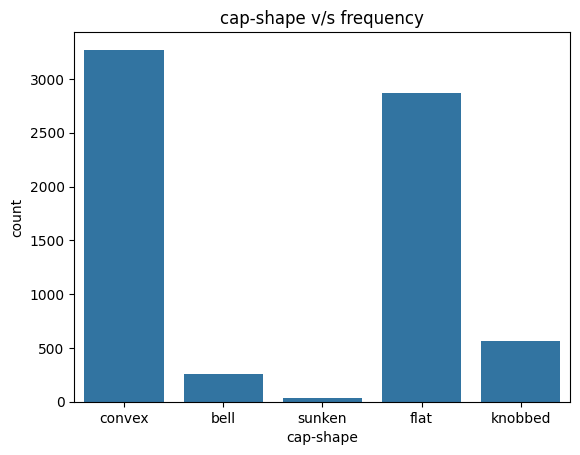

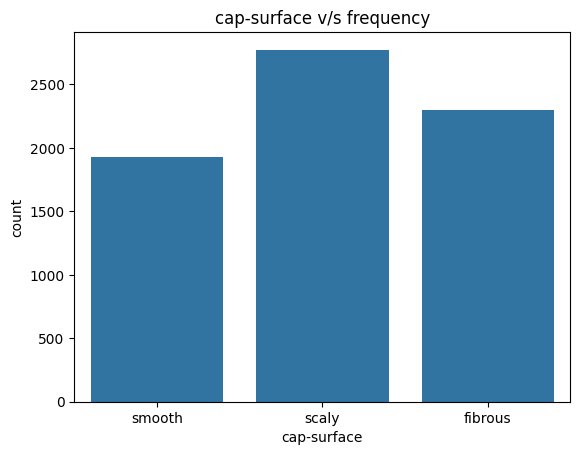

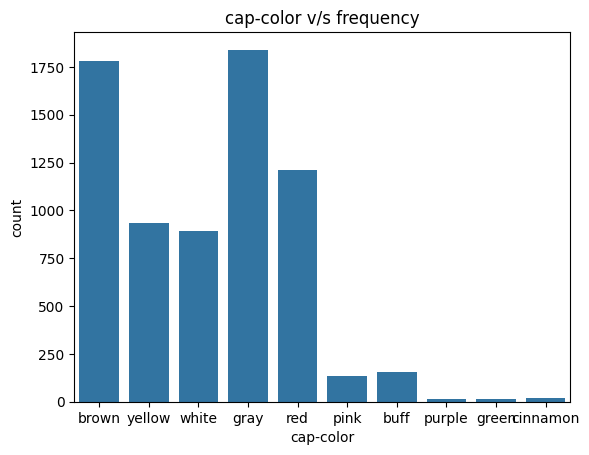

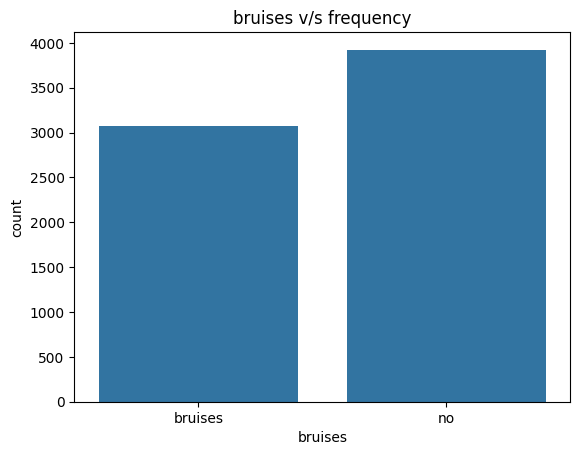

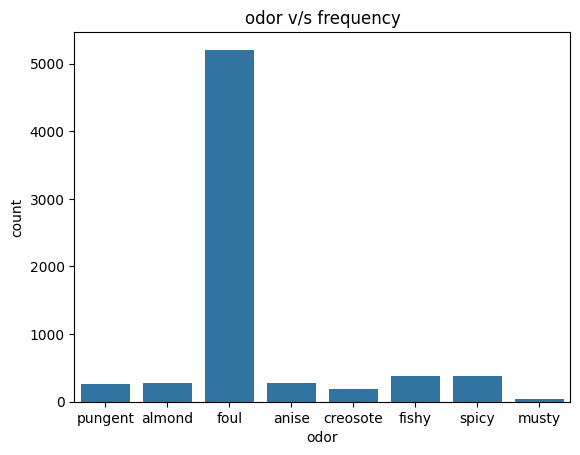

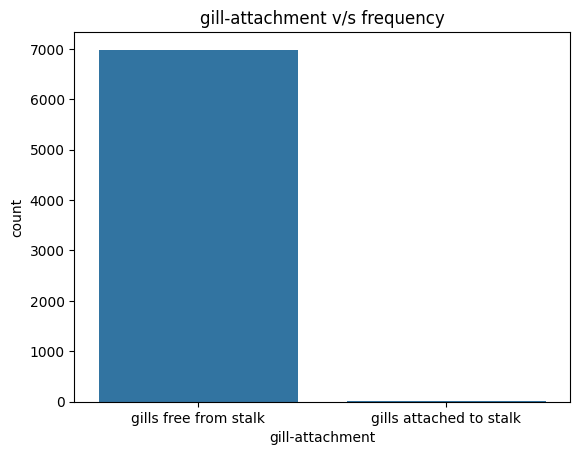

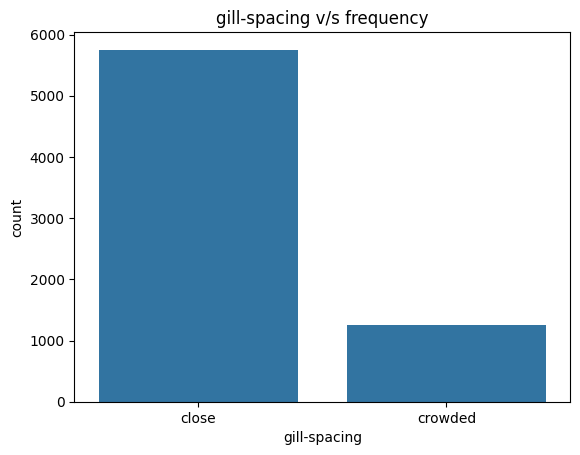

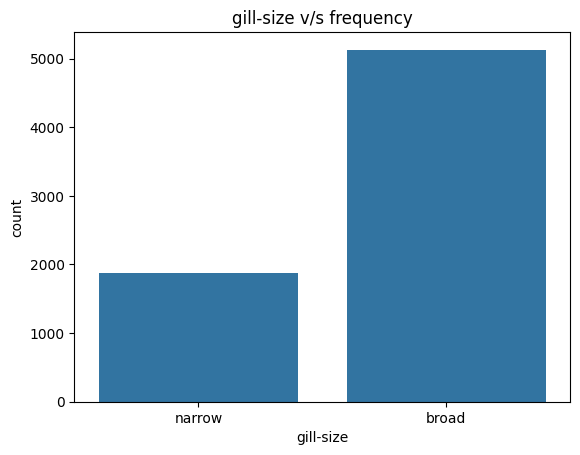

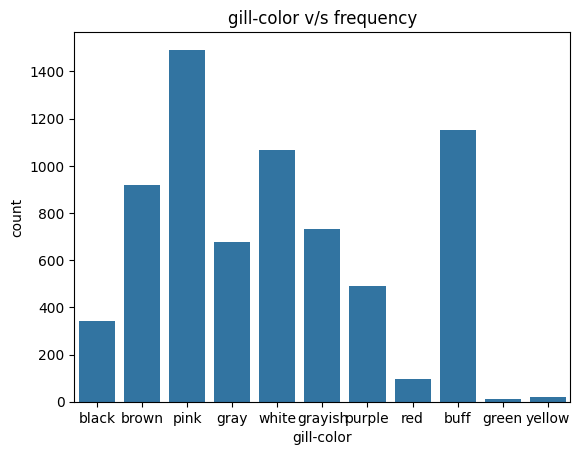

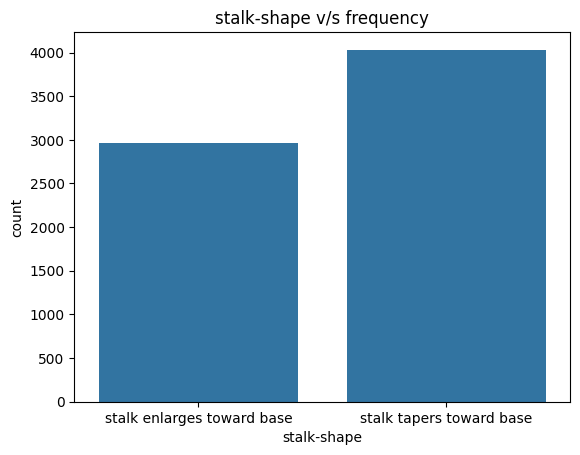

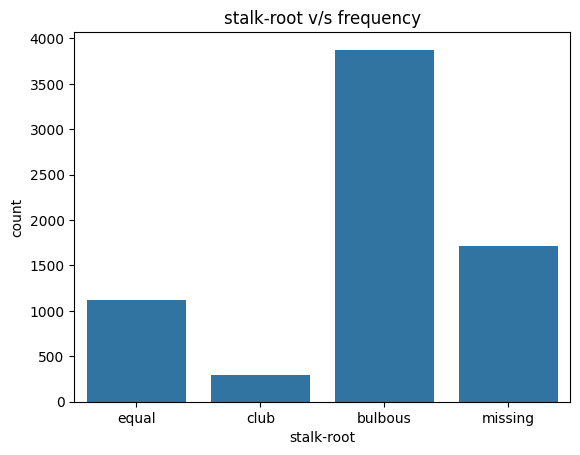

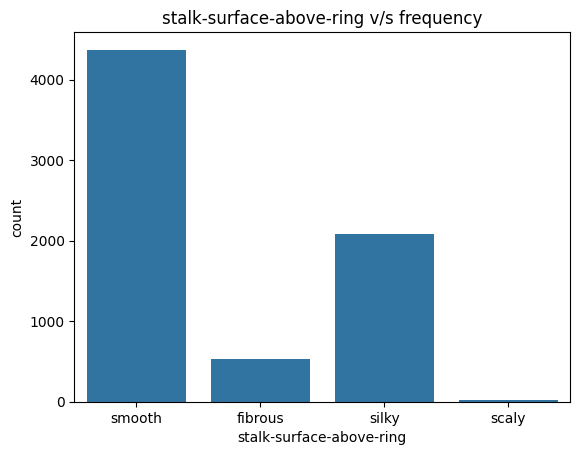

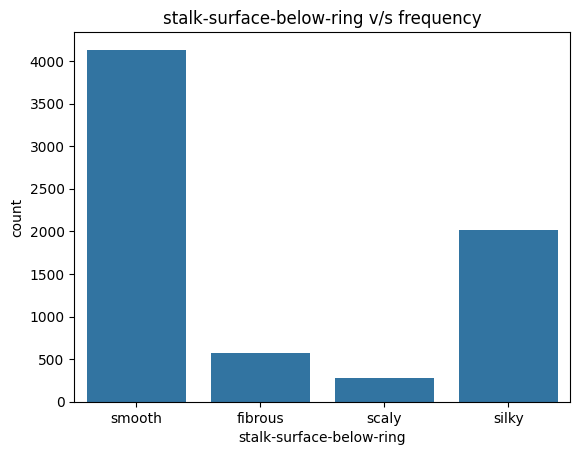

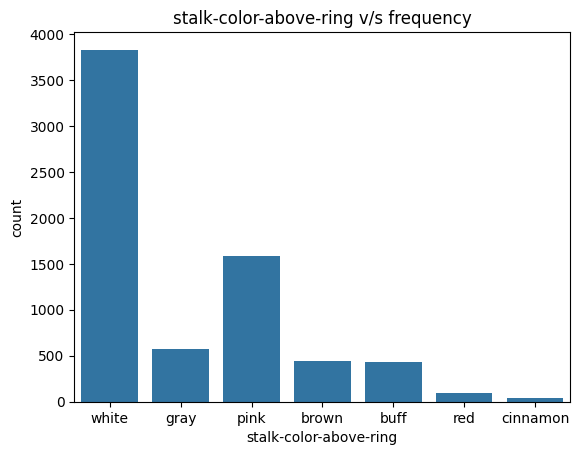

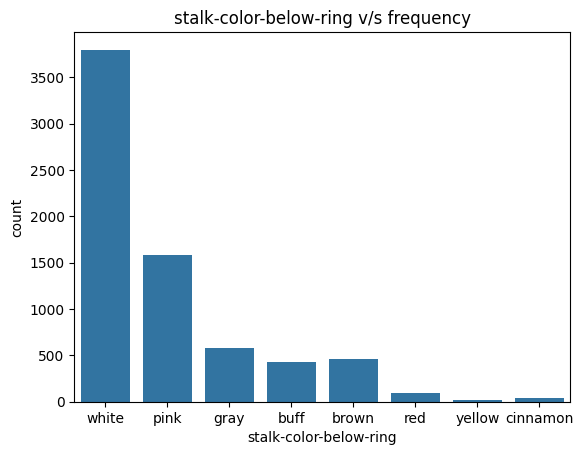

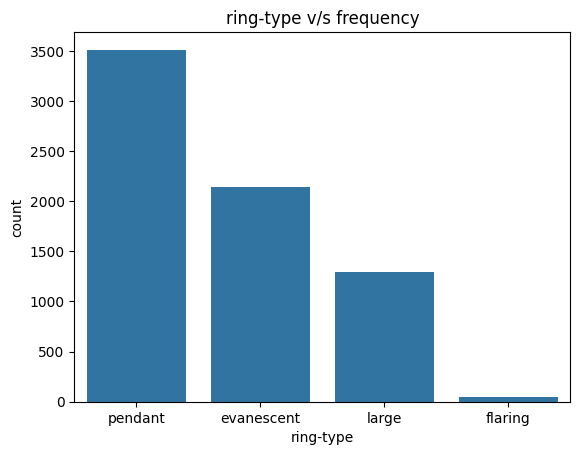

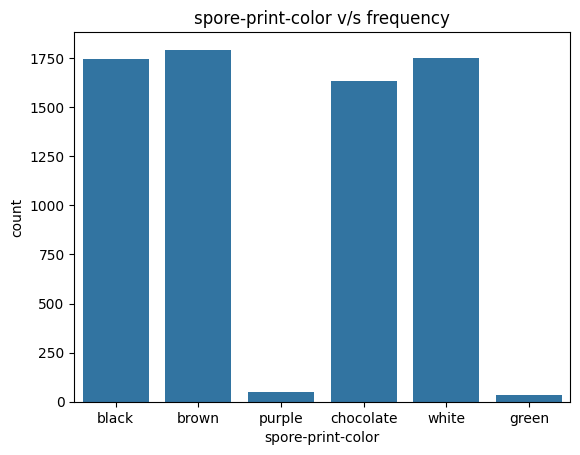

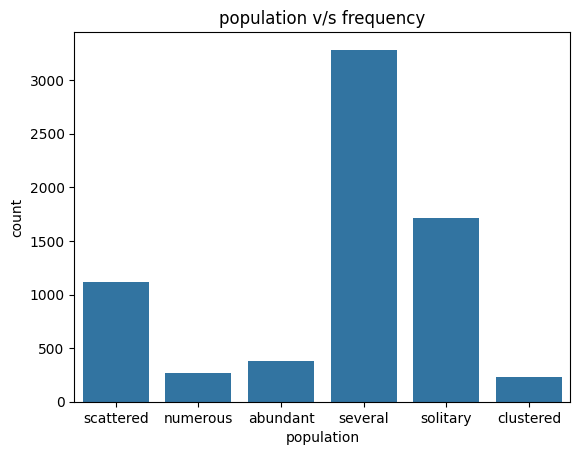

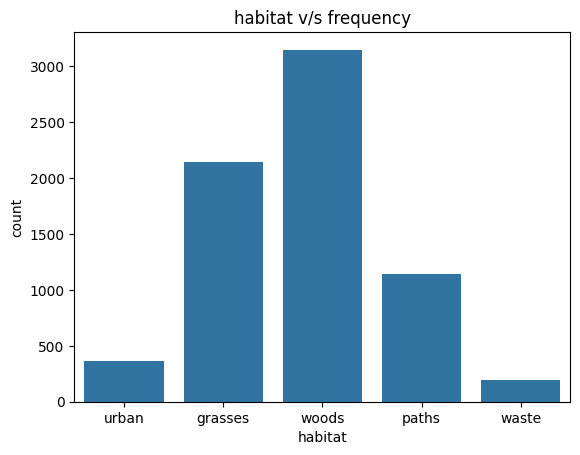

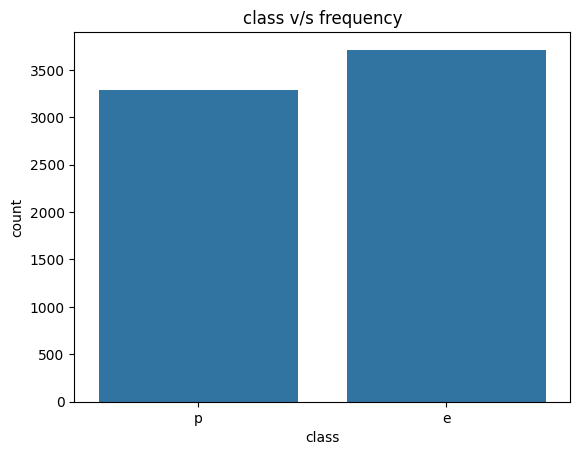

In [19]:
categorical_cols = [i for i in df.columns if i not in numericals_cols]
for i in categorical_cols:
    plt.title(f"{i} v/s frequency")
    sns.countplot(data = train_viz, x = i)
    plt.show()

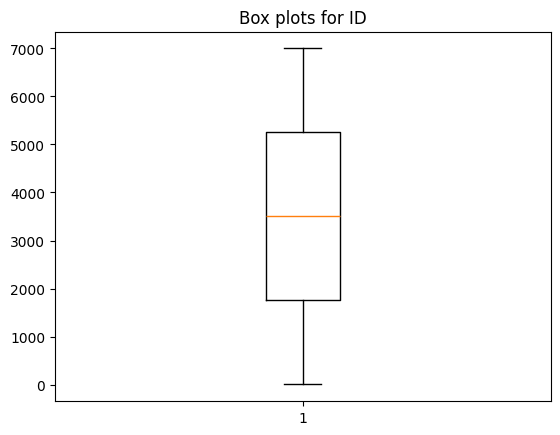

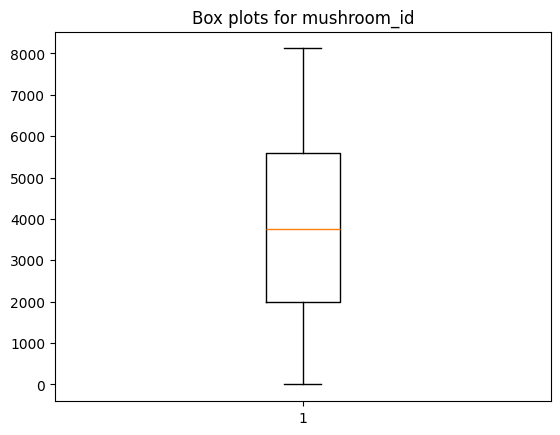

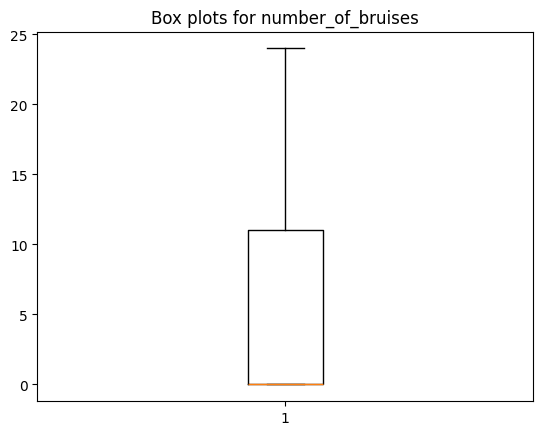

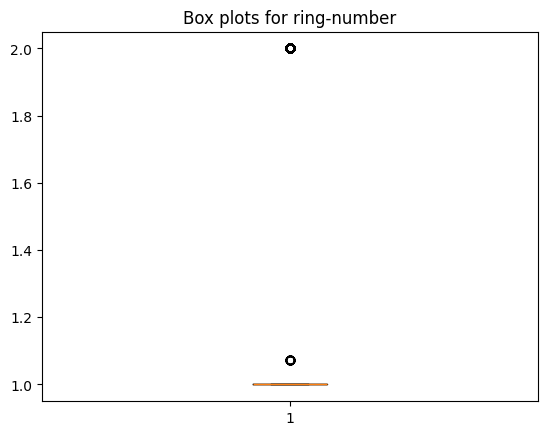

In [20]:
for i in numericals_cols[:-1]:
    plt.title(f"Box plots for {i}")
    plt.xlabel = i
    plt.boxplot(train_viz[i])
    # plt.violinplot(train[i])
    plt.show()

'\n> observation:\n    1. ID and Mushroom_id are redundent can drop either one or em\n    2. not much correlation between no of bruises and ring-number.. baerly 0.2\n'

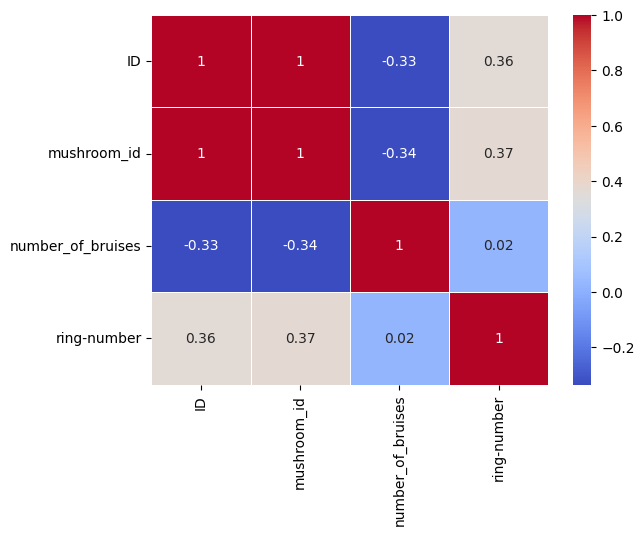

In [21]:
crr_matrix = train_viz.select_dtypes(include=["int64", "float64"]).drop(["is_train"], axis = 1).corr()
sns.heatmap(crr_matrix, annot= True, cmap= "coolwarm", linewidths=0.5)
"""
> observation:
    1. ID and Mushroom_id are redundent can drop either one or em
    2. not much correlation between no of bruises and ring-number.. baerly 0.2
"""

## Separting test and train data

In [22]:
train_df = df[df["is_train"]==1]
test_df = df[df["is_train"]==0]

train_df = train_df.drop(["is_train"], axis = 1)
test_df = test_df.drop(["is_train"], axis = 1)

In [23]:
train_df.shape, train.shape, test_df.shape, test.shape #to verify there's no leakage

((7000, 22), (7000, 27), (1124, 22), (1124, 26))

In [24]:
#splitting dataset 
from sklearn.model_selection import train_test_split
X = train_df.drop(["class"], axis = 1)
y = train_df["class"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size= 0.2, random_state=42, stratify=y
)

In [25]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
scalar = StandardScaler()
ohe = OneHotEncoder(handle_unknown='ignore')

In [26]:
X_train_num = scalar.fit_transform(X_train[["number_of_bruises", "ring-number"]])
X_val_num = scalar.transform(X_val[["number_of_bruises", "ring-number"]])
X_test_num = scalar.transform(test_df[["number_of_bruises", "ring-number"]])

X_train_cat = ohe.fit_transform(X_train[categorical_cols[:-1]])
X_val_cat = ohe.transform(X_val[categorical_cols[:-1]])
X_test_cat = ohe.transform(test_df[categorical_cols[:-1]])
# test_df.columns

In [27]:
X_train_final = np.hstack((X_train_num, X_train_cat.toarray()))
X_val_final = np.hstack((X_val_num, X_val_cat.toarray()))
X_test_final = np.hstack((X_test_num, X_test_cat.toarray()))

In [28]:
X_train.shape,X_train_final.shape, X_val.shape, X_val_final.shape,y_train.shape, y_val.shape

((5600, 21), (5600, 97), (1400, 21), (1400, 97), (5600,), (1400,))

# Model Training 

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier

In [30]:
models = {
    "logistic_regression": LogisticRegression(max_iter=400),
    "decision_tree": DecisionTreeClassifier(),
    "random_forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "gradient_boosting": GradientBoostingClassifier(),
    "adaboost": AdaBoostClassifier(),
    "svm": SVC(),
    "linear_svm": LinearSVC()
}
from sklearn.metrics import accuracy_score

In [31]:
res = {}
for i, model in models.items():
    model.fit(X_train_final, y_train)
    pred_val = model.predict(X_val_final)
    accuracy = accuracy_score(y_val, pred_val)
    print(f"{i} with accuracy: {accuracy:.3f}")
    res[i] = accuracy


logistic_regression with accuracy: 1.000
decision_tree with accuracy: 1.000
random_forest with accuracy: 1.000
KNN with accuracy: 1.000
gradient_boosting with accuracy: 1.000
adaboost with accuracy: 0.994
svm with accuracy: 1.000
linear_svm with accuracy: 1.000


/tmp/ipykernel_161517/1564570098.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "acc", y = "models", data = res_df, palette= "viridis")


<Axes: xlabel='acc', ylabel='models'>

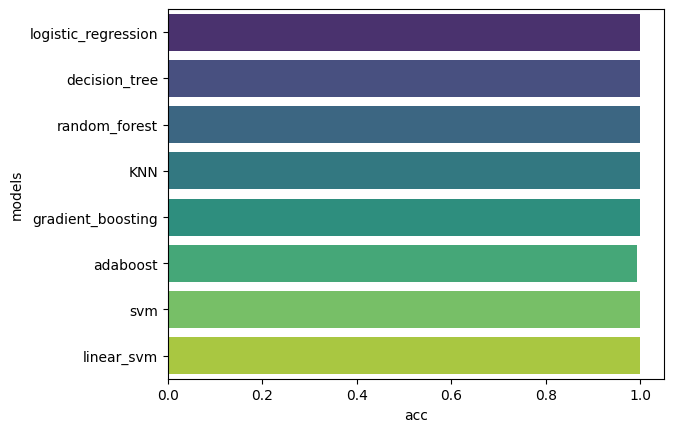

In [32]:
res_df = pd.DataFrame(list(res.items()), columns = ["models", "acc"])
sns.barplot(x = "acc", y = "models", data = res_df, palette= "viridis")

# HPT

In [ ]:
from sklearn.model_selection import GridSearchCV

rf_grid =GridSearchCV(
    RandomForestClassifier(),
    {"n_estimators":[100, 200],
    "max_depth":[None, 10]},
    cv = 3
)

svm_grid = GridSearchCV(
    SVC(),
    {"C": [0.1,1], "kernel": ["rbf", "linear"]},
    cv=3
)

ada_grid = GridSearchCV(
    AdaBoostClassifier(),
    {"n_estimators":[40,100], "learning_rate":[0.5,1]},
    cv=3
)

models = {"Random Forest":rf_grid, "AdaBoostClassifier":ada_grid, "SVM":svm_grid,}
for name, model in models.items():
    model.fit(X_train_final, y_train)
    print(f"{name} best parameter are: {model.best_params_}")

Random Forest best parameter are: {'max_depth': None, 'n_estimators': 100}
AdaBoostClassifier best parameter are: {'learning_rate': 1, 'n_estimators': 100}
SVM best parameter are: {'C': 0.1, 'kernel': 'linear'}


In [44]:
# Ensemble:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier

rfc = RandomForestClassifier(n_estimators=100, max_depth=None)
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0)

vtc = VotingClassifier(
    estimators=[("rf", rfc), ("gbc", gbc)],
    voting='soft' 
)

vtc.fit(X_train_final, y_train)
print(f"Ensemble Acc: {vtc.score(X_val_final, y_val):.4f}")

Ensemble Acc: 1.0000


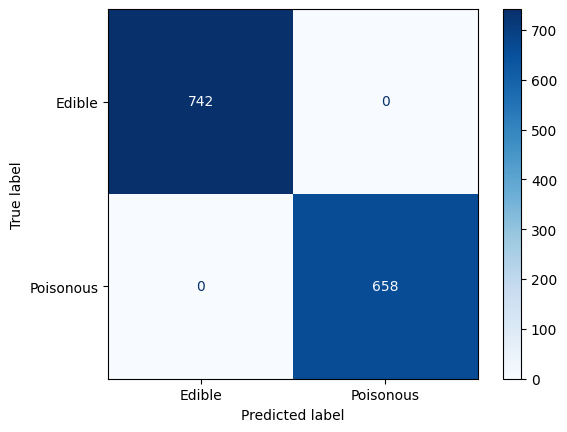

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = vtc.predict(X_val_final)
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Edible', 'Poisonous'])
disp.plot(cmap='Blues')
plt.show()

In [164]:
test_preds= model.predict(X_test_final)

In [167]:
sample["class"] = test_preds
sample["class"] = sample["class"].map({0: 'e', 1: 'p'})

In [168]:
sample

,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e
...,...,...
1119,1120,e
1120,1121,p
1121,1122,e
1122,1123,p


# Submission

In [ ]:
print(X_train.shape, X_val.shape)
test_preds = model.predict(test_df)
sample['class'] = test_preds
sample["class"].map({0.0: 'e', 1.0: 'p'})
df[df["class"].isna()]

### CatBoost Classifier

In [86]:
from catboost import CatBoostClassifier, Pool, metrics, cv
from sklearn.metrics import accuracy_score

model = CatBoostClassifier(
    custom_loss=[metrics.Accuracy()],
    random_seed = 42,
    logging_level = 'Silent'
)

cat_features = list(range(X_train.shape[1]))

In [87]:
model.fit(
    X_train, y_train,
    cat_features=cat_features, 
    eval_set=(X_val, y_val),
    # logging_level='Verbose',  # you can uncomment this for text output
    use_best_model=True,
    plot=True
)

CatBoostError: 'data' is numpy array of floating point numerical type, it means no categorical features, but 'cat_features' parameter specifies nonzero number of categorical features

In [ ]:
model.fit(
    X, y,
    cat_features=cat_features,
    verbose=100
)

In [ ]:
from sklearn.metrics import accuracy_score

val_preds = model.predict(X_val)
acc = accuracy_score(y_val, val_preds)

print("Validation Accuracy:", acc)